<a target="_blank" href="https://colab.research.google.com/github/cyneuro/latent-spaces-book-colabs/blob/main/04-Latent-Spaces-In-Unsupervised-Learning/dimensionality_reduction.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Dimensionality reduction

In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_swiss_roll
from sklearn.preprocessing import StandardScaler

import os

random_state = np.random.RandomState(123)

## 1. Examples on synthetic data

We will generate synthetic Swiss Roll 3D data with 4 clusters and reduce to to 2D using different dimensionality reduction (DR) approaches.

In [41]:
# Generate synthetic data
X_high, t = make_swiss_roll(n_samples = 1500, random_state = random_state)

# Quantile-based bins (equal number of points per cluster)
n_clusters = 4
bins = np.quantile(t, np.linspace(0, 1, n_clusters + 1))
y_clusters = np.digitize(t, bins[1:-1])

# Scale the data (important for most DR methods)
scaler = StandardScaler()
X_high_scaled = scaler.fit_transform(X_high)

print(f"Original shape: {X_high_scaled.shape}")

Original shape: (1500, 3)


In [42]:
np.linspace(t.min(), t.max(), 4)

array([ 4.71722578,  7.85453421, 10.99184264, 14.12915108])

Text(0.5, 0, 'Z')

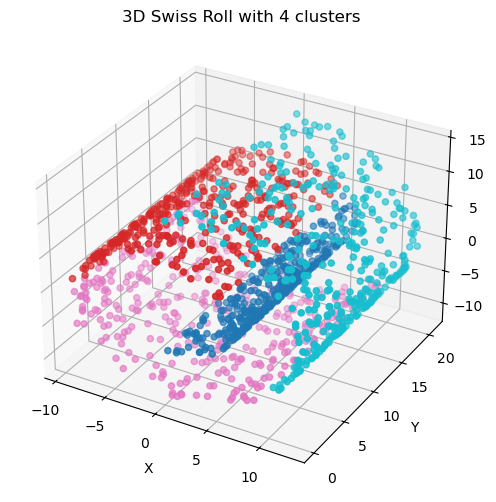

In [46]:
fig = plt.figure(figsize = (8, 6))
ax = fig.add_subplot(111, projection = '3d')

ax.scatter(X_high[:, 0], X_high[:, 1], X_high[:, 2], c = y_clusters, cmap = "tab10")
ax.set_title(f"3D Swiss Roll with {len(np.unique(y_clusters))} clusters")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

In [65]:
# Helper function to plot 2D embeddings
def plot_embedding(X_low, y_clusters, method_name):
    fig, ax = plt.subplots(1, 1, figsize = (8, 6))

    for cluster_idx in range(n_clusters):
        ax.scatter(
            X_low[y_clusters == cluster_idx, 0], 
            X_low[y_clusters == cluster_idx, 1],
            alpha = 0.8,
            label = cluster_idx
            )

    ax.set_title(method_name)
    ax.set_xlabel("Latent dimension 1")
    ax.set_ylabel("Latent dimension 2")
    ax.grid(True)

    ax.legend(title = "Cluster")
    

### Principal Component Analysis (PCA)

**Main characteristics**
- It is a **linear** method of dimensionality reduction.
- It is an **interpretable** dimensionality reduction (loadings show feature contributions).
- Data is usually scaled prior to PCA (Z-score normalization).
- The top principal components contain higher variance from the data.
- Can be used as filtering, by selecting only the top significant PCs.
- Often used as preprocessing step before nonlinear methods like t-SNE or UMAP.

**Problems**
- It performs poorly to separate cells in 0-inflated data types (because of its linear nature).
- Cell sizes, sequencing depth, and technical noise are often captured in the top principal components.

Explained variance ratio: [0.36228087 0.33193774]


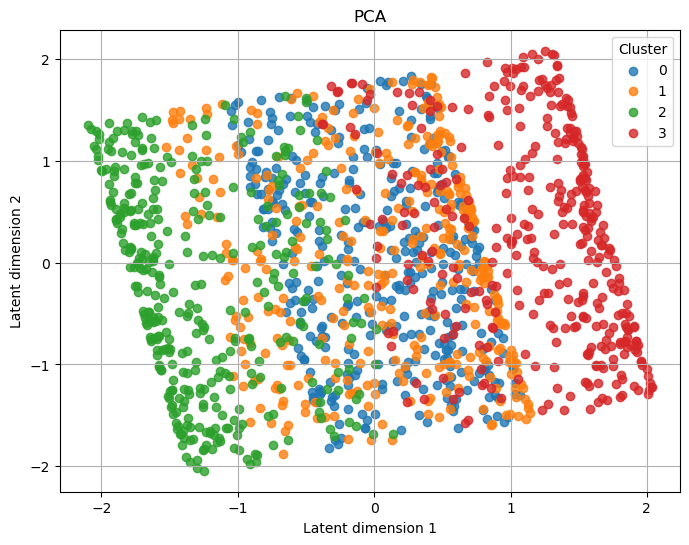

In [67]:
# PCA on synthetic data
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_high_scaled)

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")

plot_embedding(X_pca, y_clusters, "PCA")

### Multi-Dimensional Scaling (MDS)

**NOTE:** this approach may take time to run.

**Main characteristics**
- It is a distance-preserving method that embeds data to maintain pairwise (dis)similarities in lower dimensions.
- Classical MDS is linear and closely related to PCA (applied on distance/dissimilarity matrix).
- Non-metric MDS is non-linear and optimizes a stress function for ranked distances.
- Works directly with any dissimilarity matrix (Euclidean, correlation, etc.).
- Good for revealing global structure when distances are meaningful.

**Problems**
- Computationally intensive for large datasets (requires full distance matrix).
- Sensitive to outliers and noise, which can distort the embedding.
- Less effective on highly nonlinear manifolds common in scRNA-seq / EEG data.
- Does not naturally handle sparsity or zero-inflation well without preprocessing.

/Users/vladimiromelyusik/anaconda3/envs/general/lib/python3.10/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


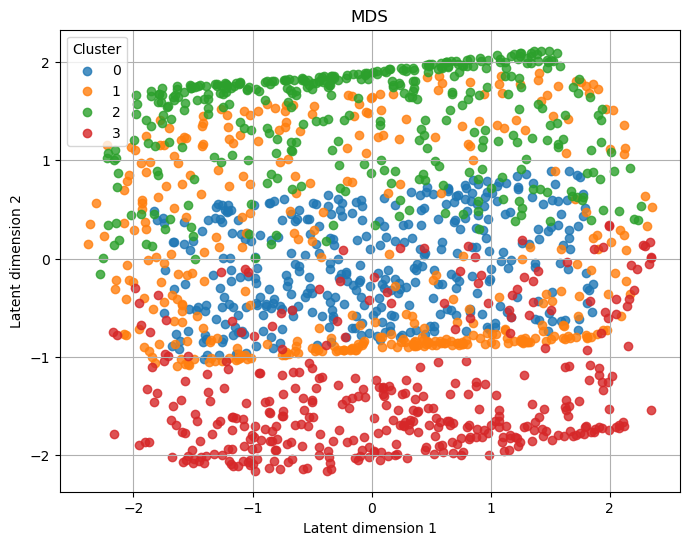

In [68]:
# MDS on synthetic data
from sklearn.manifold import MDS

mds = MDS(n_components=2, random_state=42, n_jobs=-1)
X_mds = mds.fit_transform(X_high_scaled)

plot_embedding(X_mds, y_clusters, "MDS")

### Independent Component Analysis (ICA)

**Main characteristics**
- It is a linear method that decomposes data into statistically independent components (beyond just uncorrelated, like PCA).
- Assumes non-Gaussian sources and maximizes higher-order statistics (e.g., negentropy).
- Useful for separating mixed biological signals or “expression programs”.
- Often applied after whitening (PCA preprocessing) to improve performance.
- Can reveal rare cell types or subtle independent biological processes better than variance-based methods.

**Problems**
- Requires the assumption of statistical independence and non-Gaussianity (may fail if violated).
- Sensitive to preprocessing and the number of components chosen.
- Harder to interpret than PCA in terms of variance explained.
- Performs similarly to PCA on Gaussian-like or heavily noisy data.

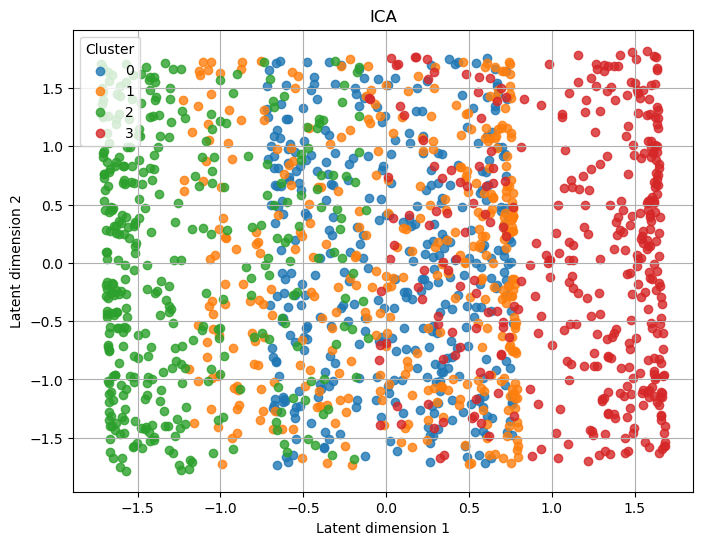

In [69]:
# ICA on synthetic data (usually after PCA whitening)
from sklearn.decomposition import FastICA

ica = FastICA(n_components=2, random_state=42)
X_ica = ica.fit_transform(X_high_scaled)

plot_embedding(X_ica, y_clusters, "ICA")

### t-SNE

**Main characteristics**
- It is a non-linear, probabilistic, graph-based method optimized for visualization.
- Excellent at preserving local neighborhoods and revealing tight clusters.
- Usually run on top PCs (e.g., PC1–PC50) as input for efficiency.
- Models similarities with Gaussian (high-dim) and t-distribution (low-dim) kernels, minimizing KL divergence.
- Considered a gold-standard for exploratory visualization in single-cell / EEG data.

**Problems**
- Does not preserve global structure well (distances between clusters can be misleading).
- Stochastic: different runs can produce varying embeddings. Needs a fixed seed for reproducibility.
- Computationally expensive (O(n²) complexity).
- Many hyperparameters (perplexity, learning rate, early exaggeration) that require empirical tuning.

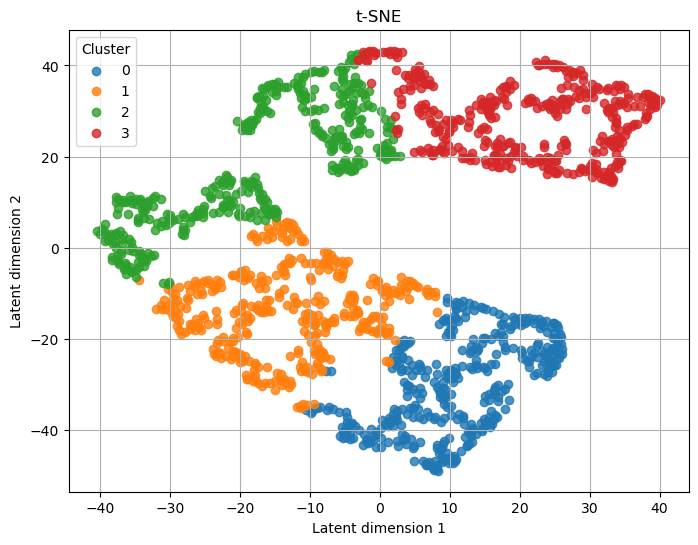

In [70]:
# t-SNE on synthetic data
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_high_scaled)

plot_embedding(X_tsne, y_clusters, "t-SNE")

### UMAP

**Main characteristics**
- It is a non-linear, graph-based manifold learning method using fuzzy topological representations.
- Balances preservation of both local and global structure better than t-SNE.
- Very efficient and scalable (O(n) complexity with approximations).
- Can be run on top PCs; supports any distance metric and supervised modes.
- Faster and more reproducible than t-SNE; allows embedding new data points.

**Problems**
- Results can still be sensitive to hyperparameters (n_neighbors, min_dist, spread).
- May over-simplify or create artificial separations in some datasets.
- Less focus on very tight local clusters compared to t-SNE in certain visualizations.
- Interpretability is lower than linear methods (no direct loadings or variance metrics).

/Users/vladimiromelyusik/anaconda3/envs/general/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


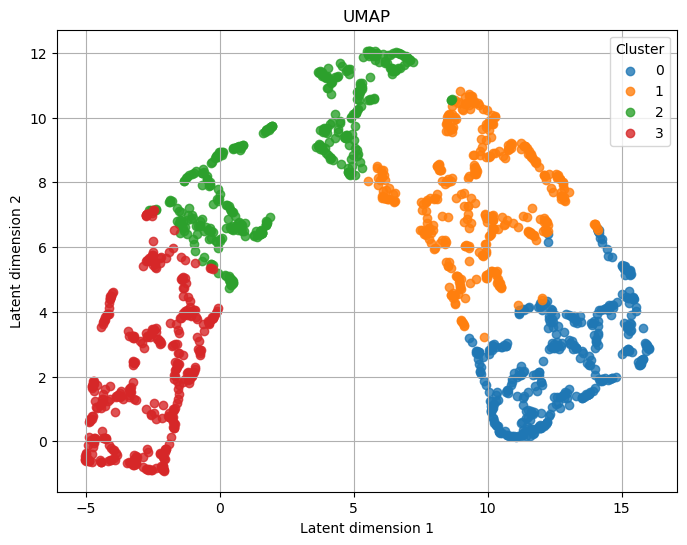

In [71]:
# UMAP on synthetic data
# Note: run `pip install umap-learn` if not installed
try:
    from umap import UMAP
except ImportError:
    print("Please install umap-learn: pip install umap-learn")
    UMAP = None

if UMAP is not None:
    umap_model = UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=random_state)
    X_umap = umap_model.fit_transform(X_high_scaled)
    plot_embedding(X_umap, y_clusters, "UMAP")

### Questions

Comment on which methods successfully reduced the dimensionality and explain why.

## 2. Neural trajectories on the EEG Emotion Dataset

We are going to work with the dataset that contains EEG signals recorded from participants playing emotionally different computer games (boring, calm, horror, funny).

1. Get familiar with [what EEG data are](https://en.wikipedia.org/wiki/Electroencephalography), [electrode positioning systmes](https://en.wikipedia.org/wiki/10–20_system_(EEG)) and the notion of a [montage](https://www.learningeeg.com/montages-and-technical-components).

2. Read about [the dataset structure](https://www.kaggle.com/datasets/wajahat1064/emotion-recognition-using-eeg-and-computer-games?resource=download). We are going to work with the data from participant S01 placed in the `data/` folder. If running in Colab, upload the [4 data files from GitHub](https://github.com/cyneuro/latent-spaces-book-colabs/tree/main/04-Latent-Spaces-In-Unsupervised-Learning/data) and put them into the `data/` folder.

We will investigate differences in the neural trajectories of signals from horror vs boring games.

In [165]:
# Constants
SAMPLE_RATE = 32  # Hz
GAMES = ["boring", "horror"]

Read the data and apply CAR.

In [166]:
# Read the data
data = []
for game_id, game in enumerate(GAMES):
    filepath = os.path.join("data", f"S01G{game_id + 1}AllChannels.csv")
    game_data = pd.read_csv(filepath)

    # Clean unwanted column if it exists
    if 'Unnamed: 14' in game_data.columns:
        game_data = game_data.drop(columns=['Unnamed: 14'])

    # Re-reference (CAR)
    game_data = game_data - np.nanmean(game_data, axis = 1, keepdims = True)

    # Target
    game_data["game"] = game
    
    data.append(game_data)

data = pd.concat(data, axis=0, ignore_index=True)

print(f"Data loaded: {data.shape[0]:,} samples × {data.shape[1]} columns")
data.head()

Data loaded: 76,504 samples × 15 columns


,AF3,AF4,F3,F4,F7,F8,FC5,FC6,O1,O2,P7,P8,T7,T8,game
0,-33.054929,-15.219029,-42.213929,1.652771,42.144871,-1.721629,-5.578029,-3.649829,25.755471,-9.916329,5.509171,7.437371,11.775671,17.078371,boring
1,-25.855150,-17.284350,-39.767050,-7.691350,38.083950,-12.912050,-16.537050,0.339550,20.267250,6.018150,21.482050,7.869050,20.142250,5.844750,boring
2,-24.079998,-13.130898,-34.264898,-4.595898,37.469002,-2.875128,-6.282598,-3.313298,24.577802,-5.688698,5.955802,6.174502,12.890602,7.163702,boring
3,-23.427304,-9.279004,-31.072904,-1.737504,34.428996,6.387696,-6.938704,-0.050004,18.454896,-8.067404,2.877996,2.602056,6.022696,9.798496,boring
4,-18.922641,-9.479641,-29.001841,-3.836941,35.462259,0.908249,-12.582441,1.123359,13.215759,-0.627961,8.214359,-1.204041,8.278359,8.453159,boring


Look at the data from 1 electrode.

In [167]:
# List available electrodes for easy selection
available = [col for col in data.columns if col not in ['game']]
print("Available electrodes:", available)

# Choose one electrode
electrode = "F4" # Try: F3, F4, F7, F8, FC5, FC6, O1, O2, P7, P8, T7, T8

Available electrodes: ['AF3', 'AF4', 'F3', 'F4', 'F7', 'F8', 'FC5', 'FC6', 'O1', 'O2', 'P7', 'P8', 'T7', 'T8']


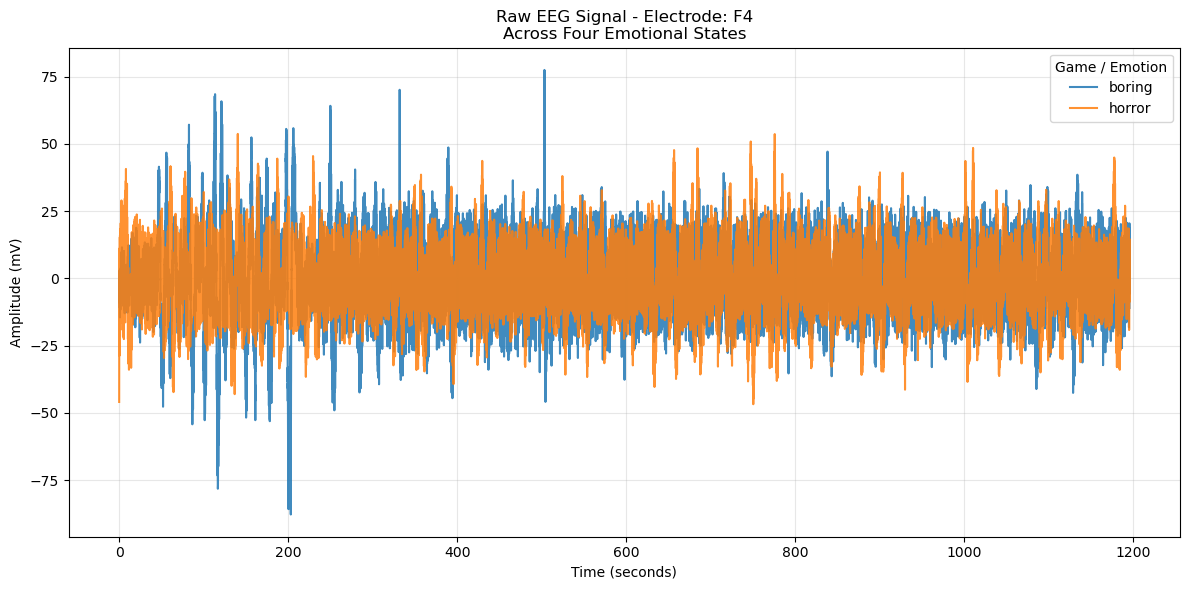

In [168]:
# Plot the selected electrode
fig, ax = plt.subplots(figsize=(12, 6))

for game in GAMES:
    mask = data["game"] == game
    signal = data.loc[mask, electrode].values
    time = np.arange(len(signal)) / SAMPLE_RATE

    ax.plot(time, signal, label=game, alpha=0.85)

ax.set_xlabel("Time (seconds)")
ax.set_ylabel("Amplitude (mV)")
ax.set_title(f"Raw EEG Signal - Electrode: {electrode}\nAcross Four Emotional States")
ax.legend(title="Game / Emotion")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Experiment

Simultaneous activation across electrodes may represent a neural patterns that differentiate horror and boring states. These patterns may not be immediately obvious from the visual analysis of time signals, but may produce a latent space that separates the two emotions.

Here we will construct a **neural trajectory** – a time point-by-time point reduction across electrodes – and analyze their behavior in the latent space.

In [169]:
X, y = data[available], data["game"]
X.shape # (n_time_samples, n_electrodes)

(76504, 14)

In [170]:
X.head()

,AF3,AF4,F3,F4,F7,F8,FC5,FC6,O1,O2,P7,P8,T7,T8
0,-33.054929,-15.219029,-42.213929,1.652771,42.144871,-1.721629,-5.578029,-3.649829,25.755471,-9.916329,5.509171,7.437371,11.775671,17.078371
1,-25.855150,-17.284350,-39.767050,-7.691350,38.083950,-12.912050,-16.537050,0.339550,20.267250,6.018150,21.482050,7.869050,20.142250,5.844750
2,-24.079998,-13.130898,-34.264898,-4.595898,37.469002,-2.875128,-6.282598,-3.313298,24.577802,-5.688698,5.955802,6.174502,12.890602,7.163702
3,-23.427304,-9.279004,-31.072904,-1.737504,34.428996,6.387696,-6.938704,-0.050004,18.454896,-8.067404,2.877996,2.602056,6.022696,9.798496
4,-18.922641,-9.479641,-29.001841,-3.836941,35.462259,0.908249,-12.582441,1.123359,13.215759,-0.627961,8.214359,-1.204041,8.278359,8.453159


In [ ]:
# TODO: scale the data
sclaler = ...
X_scaled = ...

In [ ]:
# TODO: take the first n_seconds to speed up computation
n_seconds = 10

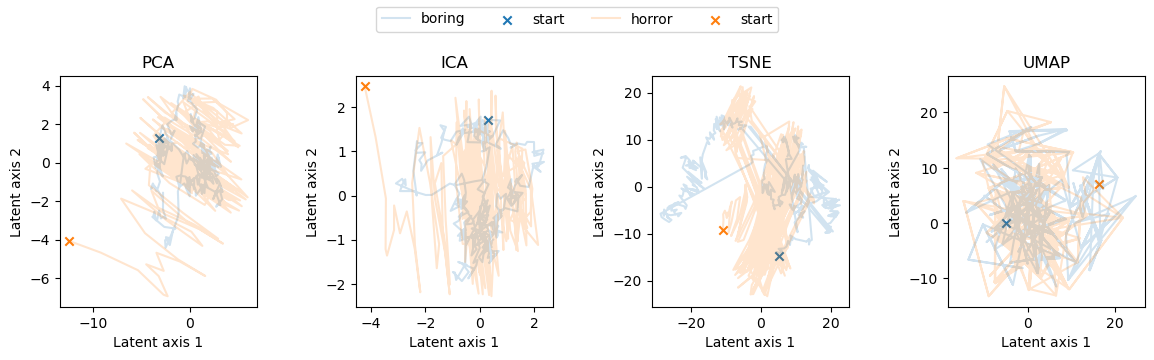

In [174]:
reducers = [PCA(2), FastICA(2), TSNE(2), UMAP(2)]
reducer_names = ["PCA", "ICA", "TSNE", "UMAP"]

fig, ax = plt.subplots(1, 4, figsize = (14, 3))

for col_id, reducer in enumerate(reducers):
    for game in GAMES:

        X_scaled_game = X_scaled[y == game][:(n_seconds * SAMPLE_RATE)]

        X_proj = reducer.fit_transform(X_scaled_game)

        # Plot neural trajectory
        ax[col_id].plot(X_proj[:, 0], X_proj[:, 1], alpha = 0.2, label = game)
        ax[col_id].scatter(X_proj[0, 0], X_proj[0, 1], marker = "x", label = "start")

        ax[col_id].set_xlabel("Latent axis 1")
        ax[col_id].set_ylabel("Latent axis 2")
        ax[col_id].set_title(reducer_names[col_id])

plt.subplots_adjust(wspace = 0.5)
fig.suptitle(" ", y = 1.1)
fig.legend(*ax[0].get_legend_handles_labels(), ncol = 4, loc = "upper center")

## Questions

Give detailed answers to the following questions.

1. What makes the trajectories "separable"?
2. Which DR methods produce separable neural trajectories? Why? 
3. Does the "separability effect" persist as you vary the number of observations?